In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"parralex","key":"0c383bd852eb531b27efea09f239a555"}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:12<00:00, 191MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

**Validation data galat hai dataset mein**

In [ ]:
train_dir = 'data/chest_xray/train'
val_dir = 'data/chest_xray/val'
test_dir = 'data/chest_xray/test'
batch_size = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9419 - loss: 0.1489 - val_accuracy: 0.8750 - val_loss: 0.3933
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9377 - loss: 0.1551 - val_accuracy: 0.7500 - val_loss: 0.6051
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9411 - loss: 0.1500 - val_accuracy: 0.9375 - val_loss: 0.3616
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9434 - loss: 0.1434 - val_accuracy: 0.7500 - val_loss: 0.5275
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9457 - loss: 0.1354 - val_accuracy: 0.8125 - val_loss: 0.3977
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9500 - loss: 0.1269 - val_accuracy: 0.5625 - val_loss: 1.4954
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9444 - loss: 0.1370 - val_accuracy: 0.6250 - val_loss: 0.6929
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9482 - loss: 0.1380 - val_accuracy: 0.6875 - v

In [ ]:
for layer in base_model.layers[-80:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
)

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.8353 - loss: 0.7329 - val_accuracy: 0.5000 - val_loss: 4.7698
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8923 - loss: 0.3319 - val_accuracy: 0.5000 - val_loss: 5.3108
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9124 - loss: 0.2452 - val_accuracy: 0.5000 - val_loss: 3.1340
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9156 - loss: 0.2121 - val_accuracy: 0.5625 - val_loss: 1.2797
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9277 - loss: 0.1657 - val_accuracy: 0.6875 - val_loss: 0.6881
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9279 - loss: 0.1839 - val_accuracy: 0.7500 - val_loss: 0.4412
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9270 - loss: 0.1871 - val_accuracy: 0.6875 - val_loss: 1.0513
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9329 - loss: 0.1692 - val_accuracy: 0.8125 - v

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Final Test Accuracy:", test_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 479ms/step - accuracy: 0.8654 - loss: 0.3085
Final Test Accuracy: 0.8653846383094788


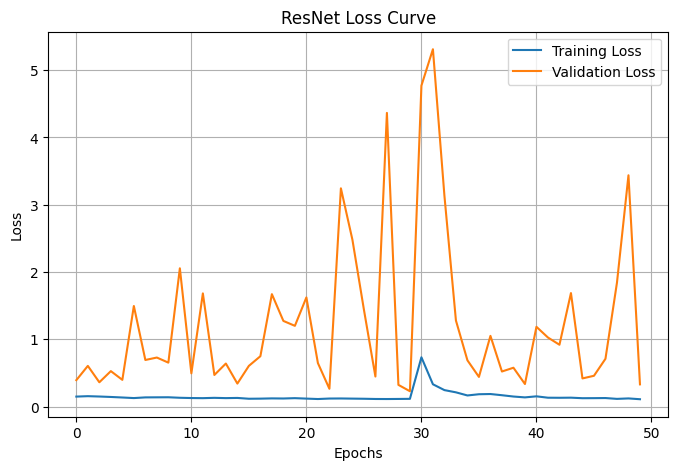

In [ ]:
import matplotlib.pyplot as plt

# Combine Stage 1 + Stage 2 losses
train_loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Plot
plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.title('ResNet Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

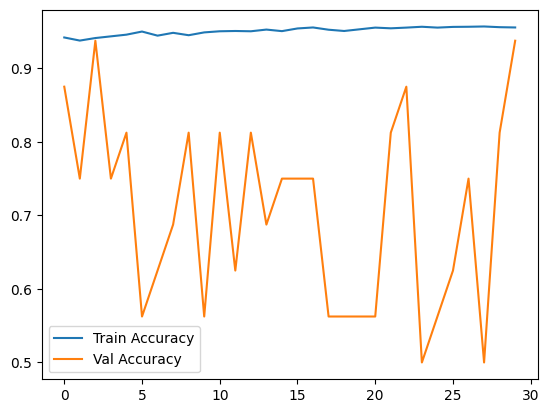

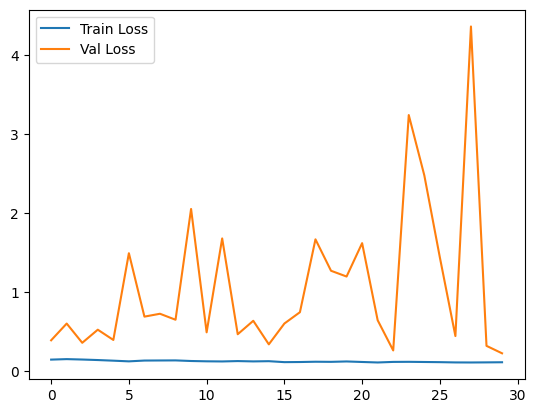

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.show()

plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.show()

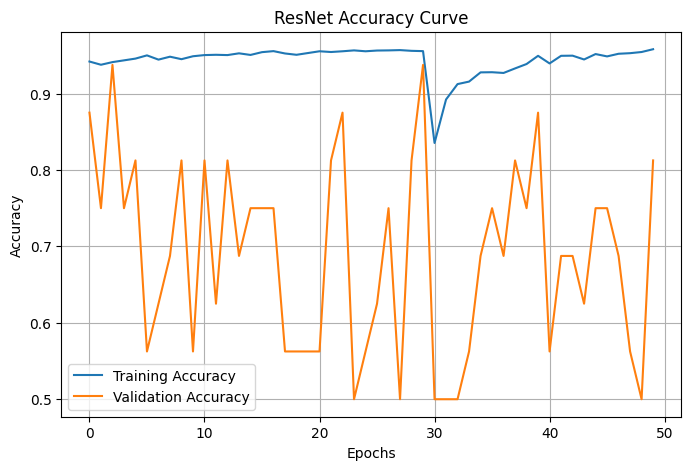

In [ ]:
train_acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

plt.figure(figsize=(8,5))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.title('ResNet Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 583ms/step - accuracy: 0.8654 - loss: 0.3085
Test Accuracy: 0.8653846383094788


10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 445ms/step


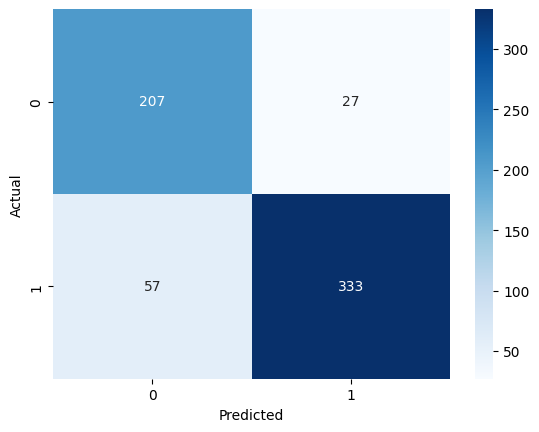

In [ ]:
predictions = model.predict(test_data)
predicted_classes = (predictions > 0.5).astype("int32")

true_classes = test_data.classes

cm = confusion_matrix(true_classes, predicted_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
#plt.title('ResNet Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print(classification_report(true_classes, predicted_classes, target_names=['Normal', 'Pneumonia']))

              precision    recall  f1-score   support

      Normal       0.78      0.88      0.83       234
   Pneumonia       0.93      0.85      0.89       390

    accuracy                           0.87       624
   macro avg       0.85      0.87      0.86       624
weighted avg       0.87      0.87      0.87       624



In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # lower LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8342 - loss: 0.9068 - val_accuracy: 0.5000 - val_loss: 2.7296
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.8762 - loss: 0.4358 - val_accuracy: 0.5625 - val_loss: 2.1737
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.8965 - loss: 0.3041 - val_accuracy: 0.5625 - val_loss: 2.1337
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9126 - loss: 0.2391 - val_accuracy: 0.6250 - val_loss: 1.4983
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.9149 - loss: 0.2221 - val_accuracy: 0.6250 - val_loss: 1.0086
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9271 - loss: 0.1907 - val_accuracy: 0.6250 - val_loss: 1.3912
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9252 - loss: 0.1881 - val_accuracy: 0.8750 - val_loss: 0.4052
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9321 - loss: 0.1614 - val_accuracy: 0.6250 - v

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Final Test Accuracy:", test_acc)
print("Final Test Loss:", test_loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 691ms/step - accuracy: 0.8878 - loss: 0.2760
Final Test Accuracy: 0.8878205418586731
Final Test Loss: 0.27599528431892395
